<a href="https://colab.research.google.com/github/zuzuczung/Tung/blob/main/final_project_rlc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import time

from collections import deque, namedtuple
from IPython.display import display, clear_output
import ipywidgets as widgets

import torch
import torch.nn as nn
import torch.optim as optim

from google.colab import drive
drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MODEL_DIR = "/content/drive/MyDrive/robot_delivery_dqn_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Version mới để không load lại model cũ bị fail
MODEL_VERSION = "v3_clean_dynamic"

# Lần đầu để True để train lại sạch.
# Sau khi train xong, lần sau đổi thành False để load model.
FORCE_RETRAIN = False

EPISODES = 1200

print("Model folder:", MODEL_DIR)
print("Model version:", MODEL_VERSION)

Mounted at /content/drive
Device: cuda
Model folder: /content/drive/MyDrive/robot_delivery_dqn_models
Model version: v3_clean_dynamic


In [3]:
MAPS = {
    "Map 1": [
        "########",
        "#S....D#",
        "#.##...#",
        "#..#...#",
        "#..#.###",
        "#..K...#",
        "#......#",
        "########",
    ],

    "Map 2": [
        "########",
        "#S..#..#",
        "#.#.#D.#",
        "#.#....#",
        "#.#.##.#",
        "#...K..#",
        "#......#",
        "########",
    ],

    "Map 3": [
        "########",
        "#S.....#",
        "#.###..#",
        "#...#..#",
        "###.#.##",
        "#K..#D.#",
        "#......#",
        "########",
    ],

    "Map 4": [
        "########",
        "#S#....#",
        "#.#.##.#",
        "#...#D.#",
        "###.#..#",
        "#K.....#",
        "#......#",
        "########",
    ],
}


class DeliveryGridEnv:
    ACTIONS = {
        0: (-1, 0),  # UP
        1: (1, 0),   # DOWN
        2: (0, -1),  # LEFT
        3: (0, 1),   # RIGHT
    }

    def __init__(self, grid_map, max_steps=90):
        self.original_map = grid_map
        self.height = len(grid_map)
        self.width = len(grid_map[0])
        self.max_steps = max_steps

        self.walls = set()
        self.start_pos = None
        self.pickup_pos = None
        self.delivery_pos = None

        for r in range(self.height):
            for c in range(self.width):
                ch = grid_map[r][c]

                if ch == "#":
                    self.walls.add((r, c))
                elif ch == "S":
                    self.start_pos = (r, c)
                elif ch == "K":
                    self.pickup_pos = (r, c)
                elif ch == "D":
                    self.delivery_pos = (r, c)

        self.dist_to_pickup = self._compute_distance_map(self.pickup_pos)
        self.dist_to_delivery = self._compute_distance_map(self.delivery_pos)

        self.reset()

    def _compute_distance_map(self, goal):
        q = deque([goal])
        dist = {goal: 0}

        while q:
            r, c = q.popleft()

            for dr, dc in self.ACTIONS.values():
                nr, nc = r + dr, c + dc

                if not (0 <= nr < self.height and 0 <= nc < self.width):
                    continue

                if (nr, nc) in self.walls:
                    continue

                if (nr, nc) not in dist:
                    dist[(nr, nc)] = dist[(r, c)] + 1
                    q.append((nr, nc))

        return dist

    def reset(self):
        self.agent_pos = self.start_pos
        self.has_package = False
        self.done = False
        self.steps = 0
        return self._get_state()

    def _get_state(self):
        state = np.zeros(self.height * self.width + 1, dtype=np.float32)

        r, c = self.agent_pos
        idx = r * self.width + c

        state[idx] = 1.0
        state[-1] = 1.0 if self.has_package else 0.0

        return state

    def valid_actions_from_pos(self, pos):
        valid = []
        r, c = pos

        for action, (dr, dc) in self.ACTIONS.items():
            nr, nc = r + dr, c + dc

            if not (0 <= nr < self.height and 0 <= nc < self.width):
                continue

            if (nr, nc) in self.walls:
                continue

            valid.append(action)

        return valid

    def valid_actions(self):
        return self.valid_actions_from_pos(self.agent_pos)

    def _distance_to_target(self, pos, has_package):
        if has_package:
            return self.dist_to_delivery.get(pos, 999)
        return self.dist_to_pickup.get(pos, 999)

    def step(self, action):
        if self.done:
            return self._get_state(), 0.0, True, {}

        old_pos = self.agent_pos
        old_has_package = self.has_package
        old_dist = self._distance_to_target(old_pos, old_has_package)

        r, c = self.agent_pos
        dr, dc = self.ACTIONS[action]
        nr, nc = r + dr, c + dc

        reward = -0.02

        if not (0 <= nr < self.height and 0 <= nc < self.width) or (nr, nc) in self.walls:
            reward -= 1.0
            nr, nc = r, c

        self.agent_pos = (nr, nc)

        new_dist = self._distance_to_target(self.agent_pos, old_has_package)

        if new_dist < old_dist:
            reward += 0.15
        elif new_dist > old_dist:
            reward -= 0.10

        self.steps += 1

        if self.agent_pos == self.pickup_pos and not self.has_package:
            self.has_package = True
            reward += 5.0

        if self.agent_pos == self.delivery_pos and self.has_package:
            reward += 15.0
            self.done = True

        if self.steps >= self.max_steps:
            self.done = True
            reward -= 3.0

        info = {
            "agent_pos": self.agent_pos,
            "has_package": self.has_package,
            "steps": self.steps,
        }

        return self._get_state(), reward, self.done, info

    def render_array(self):
        arr = np.zeros((self.height, self.width), dtype=int)

        for r in range(self.height):
            for c in range(self.width):
                if (r, c) in self.walls:
                    arr[r, c] = 1

        pr, pc = self.pickup_pos
        dr, dc = self.delivery_pos
        ar, ac = self.agent_pos

        arr[pr, pc] = 2
        arr[dr, dc] = 3
        arr[ar, ac] = 5 if self.has_package else 4

        return arr

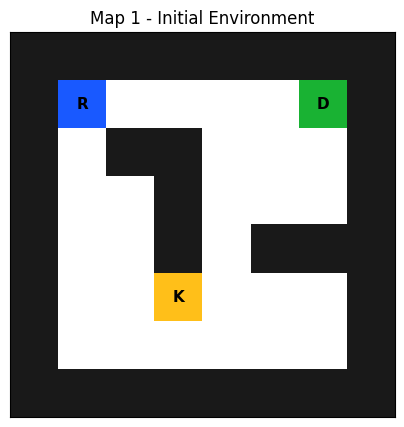

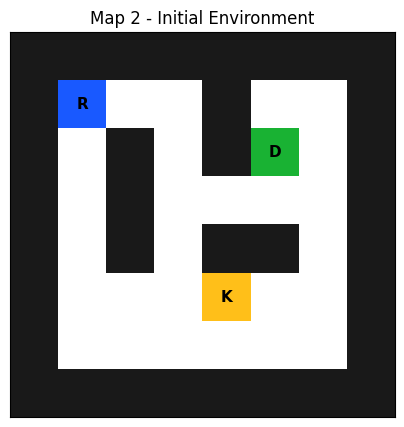

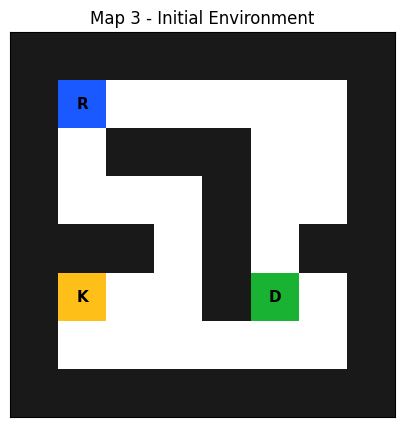

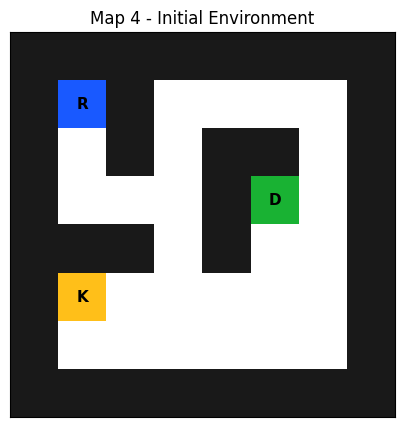

In [4]:
def render_env(env, title="Robot Delivery Grid"):
    arr = env.render_array()

    colors = {
        0: [1.0, 1.0, 1.0],      # đường đi
        1: [0.1, 0.1, 0.1],      # tường
        2: [1.0, 0.75, 0.1],     # lấy hàng
        3: [0.1, 0.7, 0.2],      # giao hàng
        4: [0.1, 0.35, 1.0],     # robot
        5: [0.7, 0.1, 1.0],      # robot có hàng
    }

    img = np.zeros((env.height, env.width, 3))

    for r in range(env.height):
        for c in range(env.width):
            img[r, c] = colors[arr[r, c]]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)

    for r in range(env.height):
        for c in range(env.width):
            text = ""

            if (r, c) == env.start_pos:
                text = "S"
            if (r, c) == env.pickup_pos:
                text = "K"
            if (r, c) == env.delivery_pos:
                text = "D"
            if (r, c) == env.agent_pos:
                text = "R" if not env.has_package else "R+K"

            if text:
                plt.text(
                    c,
                    r,
                    text,
                    ha="center",
                    va="center",
                    fontsize=11,
                    fontweight="bold"
                )

    plt.grid()
    plt.show()


def show_all_maps():
    for map_name, grid in MAPS.items():
        env = DeliveryGridEnv(grid)
        render_env(env, title=f"{map_name} - Initial Environment")


show_all_maps()

In [5]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


Transition = namedtuple(
    "Transition",
    ["state", "action", "reward", "next_state", "done"]
)


class ReplayBuffer:
    def __init__(self, capacity=30000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)

In [6]:
def select_action_masked(model, state, valid_actions, epsilon=0.0):
    if random.random() < epsilon:
        return random.choice(valid_actions)

    with torch.no_grad():
        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        q_values = model(state_tensor).squeeze(0)

        masked_q = torch.full_like(q_values, -1e9)
        masked_q[valid_actions] = q_values[valid_actions]

        action = masked_q.argmax().item()

    return action


def state_to_pos(env, state):
    idx = int(np.argmax(state[:-1]))
    r = idx // env.width
    c = idx % env.width
    return (r, c)


def build_valid_action_mask(env, states_np):
    mask = torch.zeros((len(states_np), 4), dtype=torch.bool, device=device)

    for i, state in enumerate(states_np):
        pos = state_to_pos(env, state)
        valid = env.valid_actions_from_pos(pos)
        mask[i, valid] = True

    return mask


def shortest_action_sequence(env, start, goal):
    q = deque([start])
    parent = {start: None}
    parent_action = {}

    while q:
        pos = q.popleft()

        if pos == goal:
            break

        r, c = pos

        for action, (dr, dc) in env.ACTIONS.items():
            nr, nc = r + dr, c + dc
            nxt = (nr, nc)

            if not (0 <= nr < env.height and 0 <= nc < env.width):
                continue

            if nxt in env.walls:
                continue

            if nxt not in parent:
                parent[nxt] = pos
                parent_action[nxt] = action
                q.append(nxt)

    if goal not in parent:
        return []

    actions = []
    cur = goal

    while parent[cur] is not None:
        actions.append(parent_action[cur])
        cur = parent[cur]

    actions.reverse()
    return actions


def fill_demo_replay(env, replay_buffer, n_times=80):
    """
    Nạp vài trajectory đúng vào replay buffer để DQN học nhanh hơn.
    Vẫn là DQN, phần này chỉ giúp warmup cho ổn định.
    """
    actions_to_pickup = shortest_action_sequence(
        env,
        env.start_pos,
        env.pickup_pos
    )

    actions_to_delivery = shortest_action_sequence(
        env,
        env.pickup_pos,
        env.delivery_pos
    )

    demo_actions = actions_to_pickup + actions_to_delivery

    for _ in range(n_times):
        state = env.reset()

        for action in demo_actions:
            next_state, reward, done, info = env.step(action)

            replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done)
            )

            state = next_state

            if done:
                break

In [7]:
def get_model_path(map_name):
    safe_name = map_name.replace(" ", "_").lower()
    file_name = f"dqn_{safe_name}_{MODEL_VERSION}.pth"
    return os.path.join(MODEL_DIR, file_name)


def save_dqn_model(map_name, model, history):
    save_path = get_model_path(map_name)

    checkpoint = {
        "map_name": map_name,
        "model_version": MODEL_VERSION,
        "model_state_dict": model.state_dict(),
        "history": history,
    }

    torch.save(checkpoint, save_path)
    print(f"Đã save model: {save_path}")


def safe_torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_dqn_model(map_name):
    load_path = get_model_path(map_name)

    if not os.path.exists(load_path):
        print(f"Chưa có model cho {map_name}")
        return None, None

    env = DeliveryGridEnv(MAPS[map_name])
    state_dim = env.height * env.width + 1
    action_dim = 4

    model = DQN(state_dim, action_dim).to(device)

    checkpoint = safe_torch_load(load_path)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    history = checkpoint.get("history", None)

    print(f"Đã load model: {map_name}")

    return model, history

In [8]:
def train_dqn_on_map(
    map_name,
    episodes=1200,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    target_update=20,
    epsilon_start=1.0,
    epsilon_end=0.03,
    epsilon_decay=0.995
):
    print("=" * 60)
    print(f"Training {map_name}")

    env = DeliveryGridEnv(MAPS[map_name])
    state_dim = env.height * env.width + 1
    action_dim = 4

    policy_net = DQN(state_dim, action_dim).to(device)
    target_net = DQN(state_dim, action_dim).to(device)

    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=lr)
    replay_buffer = ReplayBuffer(capacity=30000)

    fill_demo_replay(env, replay_buffer, n_times=80)

    epsilon = epsilon_start

    rewards_history = []
    success_history = []
    steps_history = []

    for ep in range(episodes):
        state = env.reset()

        total_reward = 0.0
        success = 0

        for step in range(env.max_steps):
            valid_actions = env.valid_actions()

            action = select_action_masked(
                policy_net,
                state,
                valid_actions,
                epsilon=epsilon
            )

            next_state, reward, done, info = env.step(action)

            replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done)
            )

            state = next_state
            total_reward += reward

            if len(replay_buffer) >= batch_size:
                batch = replay_buffer.sample(batch_size)

                states_np = np.array(batch.state)
                next_states_np = np.array(batch.next_state)

                states = torch.tensor(
                    states_np,
                    dtype=torch.float32,
                    device=device
                )

                actions = torch.tensor(
                    batch.action,
                    dtype=torch.long,
                    device=device
                ).unsqueeze(1)

                rewards = torch.tensor(
                    batch.reward,
                    dtype=torch.float32,
                    device=device
                ).unsqueeze(1)

                next_states = torch.tensor(
                    next_states_np,
                    dtype=torch.float32,
                    device=device
                )

                dones = torch.tensor(
                    batch.done,
                    dtype=torch.float32,
                    device=device
                ).unsqueeze(1)

                q_values = policy_net(states).gather(1, actions)

                with torch.no_grad():
                    valid_mask = build_valid_action_mask(env, next_states_np)

                    next_policy_q = policy_net(next_states)
                    next_policy_q = next_policy_q.masked_fill(~valid_mask, -1e9)

                    next_actions = next_policy_q.argmax(dim=1, keepdim=True)
                    next_q_values = target_net(next_states).gather(1, next_actions)

                    target_q_values = rewards + gamma * next_q_values * (1 - dones)

                loss = nn.SmoothL1Loss()(q_values, target_q_values)

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
                optimizer.step()

            if done:
                if env.agent_pos == env.delivery_pos and env.has_package:
                    success = 1
                break

        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        rewards_history.append(total_reward)
        success_history.append(success)
        steps_history.append(env.steps)

        if ep % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if (ep + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            avg_success = np.mean(success_history[-100:])
            avg_steps = np.mean(steps_history[-100:])

            print(
                f"{map_name} | Episode {ep + 1}/{episodes} | "
                f"Reward: {avg_reward:.2f} | "
                f"Success: {avg_success:.2f} | "
                f"Steps: {avg_steps:.1f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    history = {
        "rewards": rewards_history,
        "success": success_history,
        "steps": steps_history,
    }

    policy_net.eval()

    return policy_net, history

In [9]:
trained_models = {}
train_histories = {}

for map_name in MAPS.keys():
    print("=" * 60)
    print(f"Đang xử lý {map_name}")

    model_path = get_model_path(map_name)

    if os.path.exists(model_path) and not FORCE_RETRAIN:
        model, history = load_dqn_model(map_name)

        trained_models[map_name] = model
        train_histories[map_name] = history

        print(f"Bỏ qua train lại {map_name} vì đã có model.")
    else:
        model, history = train_dqn_on_map(
            map_name,
            episodes=EPISODES
        )

        trained_models[map_name] = model
        train_histories[map_name] = history

        save_dqn_model(map_name, model, history)

print("Xong. 4 model DQN đã sẵn sàng.")

Đang xử lý Map 1
Đã load model: Map 1
Bỏ qua train lại Map 1 vì đã có model.
Đang xử lý Map 2
Đã load model: Map 2
Bỏ qua train lại Map 2 vì đã có model.
Đang xử lý Map 3
Đã load model: Map 3
Bỏ qua train lại Map 3 vì đã có model.
Đang xử lý Map 4
Đã load model: Map 4
Bỏ qua train lại Map 4 vì đã có model.
Xong. 4 model DQN đã sẵn sàng.


In [10]:
ACTION_NAMES = {
    0: "UP",
    1: "DOWN",
    2: "LEFT",
    3: "RIGHT",
}


def ai_play(map_name, model, max_steps=90):
    env = DeliveryGridEnv(MAPS[map_name], max_steps=max_steps)
    state = env.reset()

    path = [env.agent_pos]
    package_status = [env.has_package]
    actions_taken = []

    total_reward = 0.0

    for step in range(max_steps):
        valid_actions = env.valid_actions()

        action = select_action_masked(
            model,
            state,
            valid_actions,
            epsilon=0.0
        )

        next_state, reward, done, info = env.step(action)

        actions_taken.append(ACTION_NAMES[action])
        path.append(env.agent_pos)
        package_status.append(env.has_package)

        total_reward += reward
        state = next_state

        if done:
            break

    success = env.agent_pos == env.delivery_pos and env.has_package

    result = {
        "env": env,
        "path": path,
        "package_status": package_status,
        "actions": actions_taken,
        "total_reward": total_reward,
        "success": success,
        "steps": len(actions_taken),
    }

    return result


def evaluate_all_maps():
    results = {}

    for map_name in MAPS.keys():
        model = trained_models[map_name]
        result = ai_play(map_name, model)

        results[map_name] = result

        status = "SUCCESS" if result["success"] else "FAILED"

        print(
            f"{map_name}: {status} | "
            f"Steps: {result['steps']} | "
            f"Reward: {result['total_reward']:.2f}"
        )

    return results


eval_results = evaluate_all_maps()

Map 1: SUCCESS | Steps: 13 | Reward: 21.69
Map 2: SUCCESS | Steps: 13 | Reward: 21.69
Map 3: SUCCESS | Steps: 14 | Reward: 21.82
Map 4: SUCCESS | Steps: 14 | Reward: 21.82


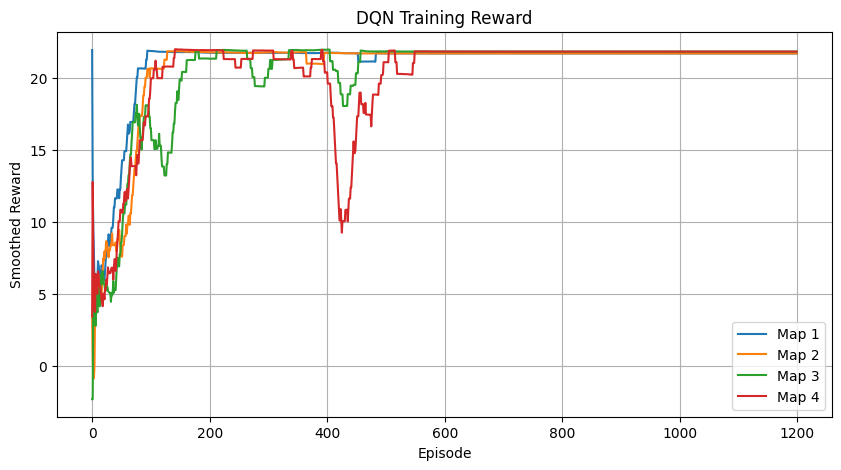

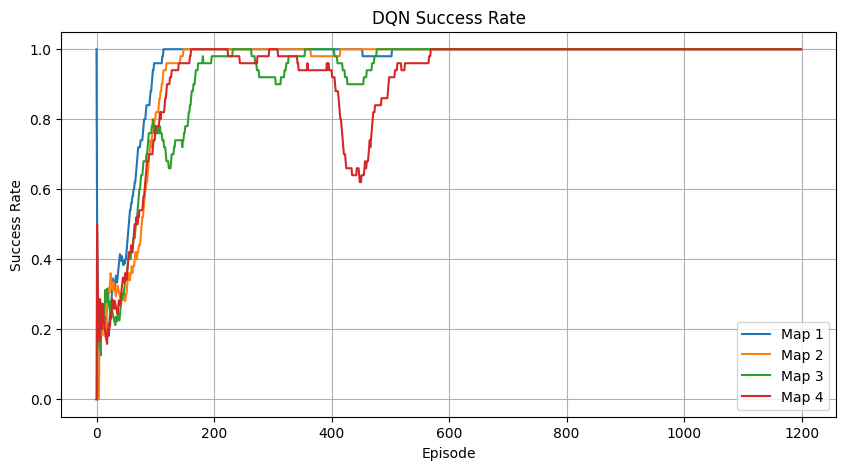

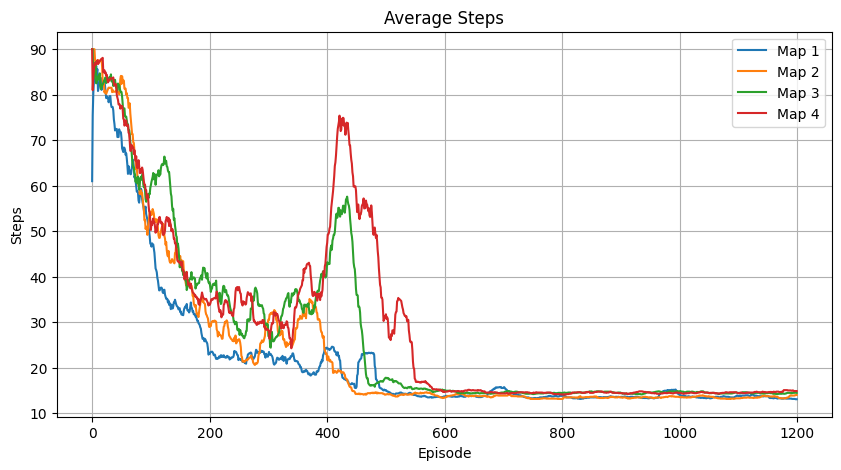

In [11]:
def moving_average(values, window=30):
    result = []

    for i in range(len(values)):
        start = max(0, i - window + 1)
        result.append(np.mean(values[start:i + 1]))

    return result


def plot_training_results(train_histories):
    valid_histories = {
        k: v for k, v in train_histories.items()
        if v is not None
    }

    if len(valid_histories) == 0:
        print("Không có history để vẽ.")
        return

    plt.figure(figsize=(10, 5))

    for map_name, history in valid_histories.items():
        rewards = history["rewards"]
        plt.plot(moving_average(rewards, 30), label=map_name)

    plt.title("DQN Training Reward")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Reward")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 5))

    for map_name, history in valid_histories.items():
        success = history["success"]
        plt.plot(moving_average(success, 50), label=map_name)

    plt.title("DQN Success Rate")
    plt.xlabel("Episode")
    plt.ylabel("Success Rate")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(10, 5))

    for map_name, history in valid_histories.items():
        steps = history["steps"]
        plt.plot(moving_average(steps, 30), label=map_name)

    plt.title("Average Steps")
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.legend()
    plt.grid()
    plt.show()


plot_training_results(train_histories)

In [12]:
#11
def draw_dynamic_frame(map_name, result, frame_idx):
    env = DeliveryGridEnv(MAPS[map_name])

    path = result["path"]
    package_status = result["package_status"]

    frame_idx = max(0, min(frame_idx, len(path) - 1))

    current_pos = path[frame_idx]
    current_has_package = package_status[frame_idx]

    img = np.zeros((env.height, env.width, 3))

    # nền map
    for r in range(env.height):
        for c in range(env.width):
            if (r, c) in env.walls:
                img[r, c] = [0.08, 0.08, 0.08]
            else:
                img[r, c] = [1.0, 1.0, 1.0]

    # đường đã đi
    for i in range(frame_idx + 1):
        r, c = path[i]
        if (r, c) not in env.walls:
            img[r, c] = [0.70, 0.88, 1.0]

    sr, sc = env.start_pos
    kr, kc = env.pickup_pos
    dr, dc = env.delivery_pos
    ar, ac = current_pos

    img[sr, sc] = [0.1, 0.35, 1.0]      # Start
    img[kr, kc] = [1.0, 0.75, 0.1]      # Pickup
    img[dr, dc] = [0.1, 0.75, 0.2]      # Delivery
    img[ar, ac] = [0.75, 0.1, 1.0]      # Robot

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)

    ax.set_xticks(np.arange(-0.5, env.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.height, 1), minor=True)
    ax.grid(which="minor")
    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )

    status = "SUCCESS" if result["success"] else "FAILED"

    ax.set_title(
        f"{map_name} | {status} | "
        f"Step {frame_idx}/{len(path)-1} | "
        f"Package: {current_has_package}"
    )

    # text trong map
    for r in range(env.height):
        for c in range(env.width):
            text = ""

            if (r, c) == env.start_pos:
                text = "S"

            if (r, c) == env.pickup_pos:
                text = "K"

            if (r, c) == env.delivery_pos:
                text = "D"

            if (r, c) == current_pos:
                text = "R" if not current_has_package else "R+K"

            if text:
                ax.text(
                    c,
                    r,
                    text,
                    ha="center",
                    va="center",
                    fontsize=12,
                    fontweight="bold",
                    color="black"
                )

    # mũi tên đường đi
    for i in range(frame_idx):
        r1, c1 = path[i]
        r2, c2 = path[i + 1]

        if (r1, c1) != (r2, c2):
            ax.arrow(
                c1,
                r1,
                c2 - c1,
                r2 - r1,
                head_width=0.15,
                length_includes_head=True,
                alpha=0.7
            )

    plt.show()

    print("Status:", status)
    print("Current step:", frame_idx, "/", len(path) - 1)

    if frame_idx > 0:
        print("Current action:", result["actions"][frame_idx - 1])
    else:
        print("Current action: START")

    print("Total reward:", round(result["total_reward"], 2))
    print("Total steps:", result["steps"])

In [13]:
import time
from IPython.display import clear_output, display

clear_output(wait=True)

# =========================
# CELL 12 - FIX GIAO DIỆN CHỌN ĐÚNG MAP
# =========================

current_result = None
current_map_name = None


map_dropdown = widgets.Dropdown(
    options=list(MAPS.keys()),
    value="Map 1",
    description="Map:",
    layout=widgets.Layout(width="250px")
)

selected_label = widgets.HTML(
    value="<b>Selected map:</b> Map 1"
)

btn_show_map = widgets.Button(
    description="Show Map",
    button_style="info",
    layout=widgets.Layout(width="150px")
)

btn_ai_dynamic = widgets.Button(
    description="AI Play Dynamic",
    button_style="success",
    layout=widgets.Layout(width="170px")
)

btn_eval_all = widgets.Button(
    description="Evaluate 4 Maps",
    button_style="primary",
    layout=widgets.Layout(width="170px")
)

btn_train_chart = widgets.Button(
    description="Training Chart",
    button_style="warning",
    layout=widgets.Layout(width="170px")
)

btn_prev = widgets.Button(
    description="Prev",
    button_style="info",
    layout=widgets.Layout(width="120px")
)

btn_next = widgets.Button(
    description="Next",
    button_style="info",
    layout=widgets.Layout(width="120px")
)

btn_auto = widgets.Button(
    description="Auto Play",
    button_style="success",
    layout=widgets.Layout(width="120px")
)

btn_reset = widgets.Button(
    description="Reset",
    button_style="warning",
    layout=widgets.Layout(width="120px")
)

step_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=1,
    step=1,
    description="Step:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

speed_slider = widgets.FloatSlider(
    value=0.35,
    min=0.1,
    max=1.0,
    step=0.05,
    description="Speed:",
    continuous_update=False,
    layout=widgets.Layout(width="400px")
)

status_output = widgets.Output()
map_output = widgets.Output()


def reset_current_result():
    global current_result, current_map_name

    current_result = None
    current_map_name = None

    step_slider.value = 0
    step_slider.min = 0
    step_slider.max = 1


def show_selected_map_only():
    map_name = str(map_dropdown.value)

    with map_output:
        clear_output(wait=True)
        env = DeliveryGridEnv(MAPS[map_name])
        render_env(env, title=f"{map_name} - Initial Environment")


def render_current_dynamic_frame():
    global current_result, current_map_name

    with map_output:
        clear_output(wait=True)

        if current_result is None or current_map_name is None:
            print("Chưa có đường đi AI. Bấm AI Play Dynamic trước.")
            return

        draw_dynamic_frame(
            current_map_name,
            current_result,
            step_slider.value
        )


def on_map_changed(change):
    if change["name"] == "value":
        selected = str(change["new"])

        selected_label.value = f"<b>Selected map:</b> {selected}"

        reset_current_result()

        with status_output:
            clear_output(wait=True)
            print(f"Đã chọn {selected}")
            print("Bấm Show Map để xem map ban đầu.")
            print("Hoặc bấm AI Play Dynamic để AI chơi map này.")

        with map_output:
            clear_output(wait=True)
            env = DeliveryGridEnv(MAPS[selected])
            render_env(env, title=f"{selected} - Initial Environment")


def on_show_map_clicked(b):
    reset_current_result()

    map_name = str(map_dropdown.value)

    with status_output:
        clear_output(wait=True)
        print(f"Selected map: {map_name}")
        print("Đang hiển thị map ban đầu.")

    with map_output:
        clear_output(wait=True)
        env = DeliveryGridEnv(MAPS[map_name])
        render_env(env, title=f"{map_name} - Initial Environment")


def on_ai_dynamic_clicked(b):
    global current_result, current_map_name

    map_name = str(map_dropdown.value)

    with status_output:
        clear_output(wait=True)
        print(f"Selected map: {map_name}")
        print(f"Đang cho AI chơi {map_name}...")

    if map_name not in trained_models:
        with status_output:
            clear_output(wait=True)
            print(f"Chưa có model cho {map_name}")
        return

    model = trained_models[map_name]
    result = ai_play(map_name, model)

    current_result = result
    current_map_name = map_name

    step_slider.min = 0
    step_slider.max = len(result["path"]) - 1
    step_slider.value = 0

    status = "SUCCESS" if result["success"] else "FAILED"

    with status_output:
        clear_output(wait=True)
        print("=" * 50)
        print(f"Selected map: {map_name}")
        print(f"{map_name}: {status}")
        print(f"Steps: {result['steps']}")
        print(f"Reward: {result['total_reward']:.2f}")
        print("=" * 50)
        print("Bấm Auto Play để robot chạy.")
        print("Hoặc kéo Step / bấm Next Prev để xem từng bước.")

    render_current_dynamic_frame()


def on_eval_all_clicked(b):
    with status_output:
        clear_output(wait=True)
        print("Đánh giá cả 4 map:")
        evaluate_all_maps()


def on_train_chart_clicked(b):
    with map_output:
        clear_output(wait=True)
        plot_training_results(train_histories)


def on_slider_change(change):
    if change["name"] == "value":
        render_current_dynamic_frame()


def on_prev_clicked(b):
    if current_result is None:
        with status_output:
            clear_output(wait=True)
            print("Bấm AI Play Dynamic trước.")
        return

    if step_slider.value > step_slider.min:
        step_slider.value -= 1
    else:
        render_current_dynamic_frame()


def on_next_clicked(b):
    if current_result is None:
        with status_output:
            clear_output(wait=True)
            print("Bấm AI Play Dynamic trước.")
        return

    if step_slider.value < step_slider.max:
        step_slider.value += 1
    else:
        render_current_dynamic_frame()


def on_reset_clicked(b):
    if current_result is None:
        with status_output:
            clear_output(wait=True)
            print("Bấm AI Play Dynamic trước.")
        return

    step_slider.value = 0
    render_current_dynamic_frame()


def on_auto_clicked(b):
    if current_result is None:
        with status_output:
            clear_output(wait=True)
            print("Bấm AI Play Dynamic trước.")
        return

    for i in range(step_slider.value, step_slider.max + 1):
        step_slider.value = i
        render_current_dynamic_frame()
        time.sleep(speed_slider.value)


map_dropdown.observe(on_map_changed, names="value")

btn_show_map.on_click(on_show_map_clicked)
btn_ai_dynamic.on_click(on_ai_dynamic_clicked)
btn_eval_all.on_click(on_eval_all_clicked)
btn_train_chart.on_click(on_train_chart_clicked)

btn_prev.on_click(on_prev_clicked)
btn_next.on_click(on_next_clicked)
btn_auto.on_click(on_auto_clicked)
btn_reset.on_click(on_reset_clicked)

step_slider.observe(on_slider_change, names="value")


ui = widgets.VBox([
    widgets.HTML("<h2>Robot Delivery Grid World - DQN Dynamic Demo</h2>"),
    widgets.HTML("<p>Chọn map → bấm <b>AI Play Dynamic</b> → bấm <b>Auto Play</b>.</p>"),

    widgets.HBox([
        map_dropdown,
        selected_label
    ]),

    widgets.HBox([
        btn_show_map,
        btn_ai_dynamic,
        btn_eval_all,
        btn_train_chart
    ]),

    widgets.HTML("<hr>"),

    status_output,

    widgets.HBox([
        btn_prev,
        btn_next,
        btn_auto,
        btn_reset
    ]),

    step_slider,
    speed_slider,

    widgets.HTML("<hr>"),

    map_output
])

display(ui)

# Hiện Map 1 ban đầu
with map_output:
    clear_output(wait=True)
    env = DeliveryGridEnv(MAPS["Map 1"])
    render_env(env, title="Map 1 - Initial Environment")